In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [16]:
df=pd.read_csv('revenue_prediction.csv')
df

,Id,Name,Franchise,Category,City,No_Of_Item,Order_Placed,Revenue
0,101,HungryHowie'sPizza,Yes,Mexican,Bengaluru,55,5.5,5953753
1,102,CharleysPhillySteaks,No,Varied Menu,Gurugram,72,6.8,7223131
2,103,Chuy's,Yes,Chicken,Pune,25,1.9,2555379
3,104,O'Charley's,Yes,Italian/Pizza,Mumbai,18,2.5,2175511
4,105,PolloTropical,Yes,Pizza,Noida,48,4.2,4816715
...,...,...,...,...,...,...,...,...
95,196,Wetzel'sPretzels,No,Italian/Pizza,Bengaluru,19,1.1,1270499
96,197,LaMadeleineCountryFrenchCafe,Yes,Varied Menu,Bengaluru,75,6.3,6412623
97,198,Giordano's,Yes,Varied Menu,Gurugram,77,6.2,6694797
98,199,IslandsFineBurgers&Drinks,Yes,Sports Bar,Pune,25,2.1,2344689


In [17]:
df.duplicated().sum()

0

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            100 non-null    int64  
 1   Name          100 non-null    object 
 2   Franchise     100 non-null    object 
 3   Category      100 non-null    object 
 4   City          100 non-null    object 
 5   No_Of_Item    100 non-null    int64  
 6   Order_Placed  100 non-null    float64
 7   Revenue       100 non-null    int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 6.4+ KB


In [19]:
df.drop(columns=['Id','Name'],inplace=True)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Franchise     100 non-null    object 
 1   Category      100 non-null    object 
 2   City          100 non-null    object 
 3   No_Of_Item    100 non-null    int64  
 4   Order_Placed  100 non-null    float64
 5   Revenue       100 non-null    int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 4.8+ KB


In [21]:
df.isnull().sum()

Franchise       0
Category        0
City            0
No_Of_Item      0
Order_Placed    0
Revenue         0
dtype: int64

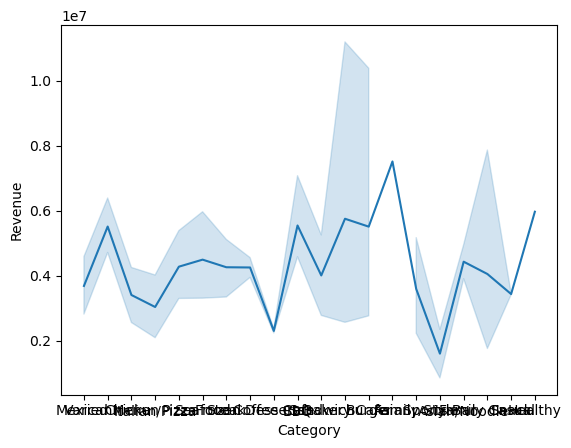

In [22]:
#visuvalization :how revenue is depending the other features.
sns.lineplot(x=df['Category'],y=df['Revenue'])
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.show()

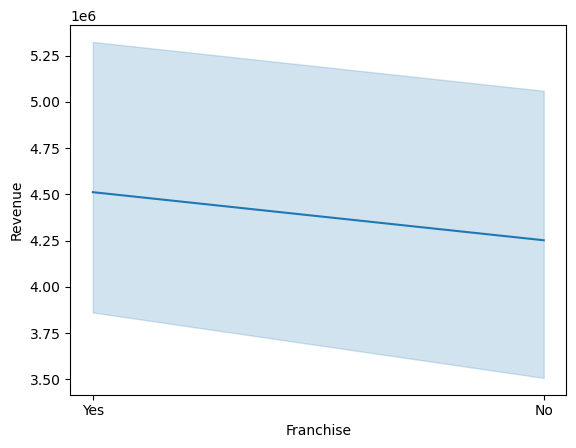

In [26]:
sns.lineplot(x=df['Franchise'],y=df['Revenue'])
plt.xlabel('Franchise')
plt.ylabel('Revenue')
plt.show()

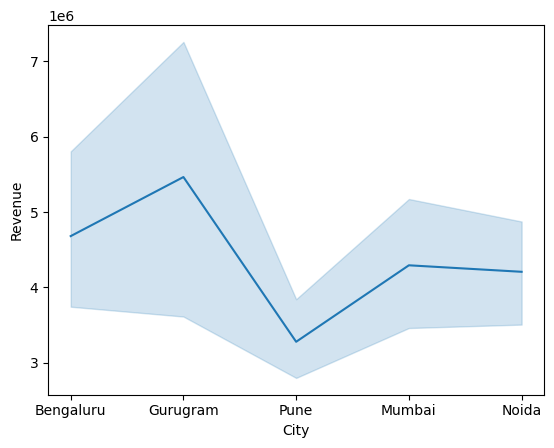

In [23]:
sns.lineplot(x=df['City'],y=df['Revenue'])
plt.xlabel('City')
plt.ylabel('Revenue')
plt.show()

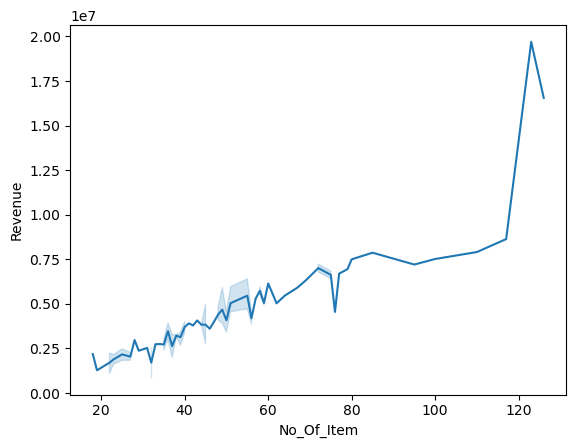

In [24]:
sns.lineplot(x=df['No_Of_Item'],y=df['Revenue'])
plt.xlabel('No_Of_Item')
plt.ylabel('Revenue')
plt.show()

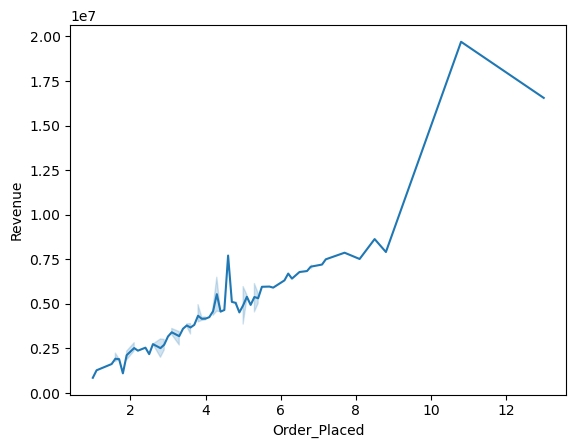

In [25]:
sns.lineplot(x=df['Order_Placed'],y=df['Revenue'])
plt.xlabel('Order_Placed')
plt.ylabel('Revenue')
plt.show()

In [ ]:
#so here important features are franchise,no_of_order_placed,no_of_items.

In [27]:
df['City'].unique()

array(['Bengaluru', 'Gurugram', 'Pune', 'Mumbai', 'Noida'], dtype=object)

In [28]:
df['Category'].unique()

array(['Mexican', 'Varied Menu', 'Chicken', 'Italian/Pizza', 'Pizza',
       'Seafood', 'Steak', 'Frozen Desserts', 'Coffee Cafe', 'BBQ',
       'Sandwich', 'Bakery Cafe', 'Burger', 'Asian', 'Family Style',
       'Sports Bar', 'Asian/Noodle', 'Family Casual', 'Snack', 'Healthy'],
      dtype=object)

In [30]:
x= df.iloc[:,:-1]
del x['Category']

In [31]:
x.columns

Index(['Franchise', 'City', 'No_Of_Item', 'Order_Placed'], dtype='object')

In [32]:
y= pd.DataFrame(df['Revenue'])

In [33]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Franchise     100 non-null    object 
 1   City          100 non-null    object 
 2   No_Of_Item    100 non-null    int64  
 3   Order_Placed  100 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.3+ KB


In [34]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
x['Franchise']=le.fit_transform(x['Franchise'])
x['City']=le.fit_transform(x['City'])

In [35]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Franchise     100 non-null    int32  
 1   City          100 non-null    int32  
 2   No_Of_Item    100 non-null    int64  
 3   Order_Placed  100 non-null    float64
dtypes: float64(1), int32(2), int64(1)
memory usage: 2.5 KB


In [71]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=20,test_size=0.30)


In [68]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred= lr.predict(x_test)

In [44]:
from sklearn.metrics import r2_score
r2_Score= r2_score(y_test,y_pred)*100
print(f'accuracy of linear model:{r2_Score}')

accuracy of linear model:91.4150773455169


In [58]:
#lets check accuracy with DecisionTreeRegressor
from sklearn.tree import DecisionTreeRegressor
dr=DecisionTreeRegressor(max_depth=7)
dr.fit(x_train,y_train)
y_pred= dr.predict(x_test)

In [59]:
from sklearn.metrics import r2_score
r2_Score= r2_score(y_test,y_pred)*100
print(f'accuracy of DecisionTreeRegressor model:{r2_Score}')

accuracy of DecisionTreeRegressor model:39.39843675740915


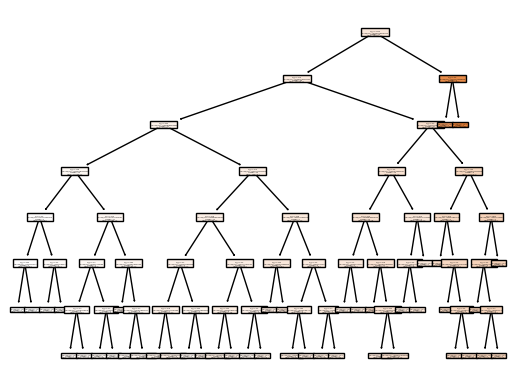

In [60]:
from sklearn.tree import plot_tree
plot_tree(dr,filled=True)
plt.show()

In [63]:
from sklearn.ensemble import RandomForestRegressor
RR=RandomForestRegressor(n_estimators=100,max_depth=7)

In [64]:
RR.fit(x_train,y_train)
RR.predict(x_test)

C:\Users\reena\AppData\Local\Temp\ipykernel_1324\4285398915.py:1: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  RR.fit(x_train,y_train)


array([ 4365772.77376068,  5285185.92252778,  2143873.17      ,
        4277919.7600406 ,  2301903.29754762,  7570020.34142857,
        1447727.72      ,  2658197.16180159,  5296919.15430159,
       11795584.72      ,  5675607.94438584,  3393407.84508333,
        2124920.33333333,  6472043.63309524,  4635878.15976587,
        1589553.77333333,  3051837.13225   ,  1469473.9       ,
        5793022.65385714,  5441694.13990079,  2555445.26163492,
        3275364.31439286,  3815094.96229823,  1387571.14      ,
        2125524.08583333,  1808313.32833333,  6616192.74642857,
        6460010.8747619 ,  2944402.06336905,  2123443.81      ])

In [65]:
from sklearn.metrics import r2_score
r2_Score= r2_score(y_test,y_pred)*100
print(f'accuracy of RandomForestRegressor model:{r2_Score}')

accuracy of RandomForestRegressor model:39.39843675740915


In [ ]:
#so here best model is linear_regression because accuracy of it is 91.45.